In [1]:
from Imports import *
from Plotting import *
from Helper import *
from Preprocessing import *
%matplotlib inline

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(device)

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

cuda
<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


(256,)
tensor([[ 0.0389,  0.1050,  0.0364,  ..., -0.0497,  0.0060, -0.0756],
        [ 0.0276, -0.1057,  0.0093,  ..., -0.0164,  0.1117, -0.0314],
        [-0.0425,  0.1203, -0.0463,  ...,  0.0412, -0.1309,  0.0530],
        ...,
        [ 0.0251,  0.0324,  0.0280,  ..., -0.0278,  0.0456, -0.0372],
        [ 0.0156, -0.0168,  0.0355,  ..., -0.0335,  0.0503, -0.0204],
        [ 0.0094, -0.2118, -0.0302,  ...,  0.0318,  0.1656,  0.0333]],
       device='cuda:0', dtype=torch.float64)


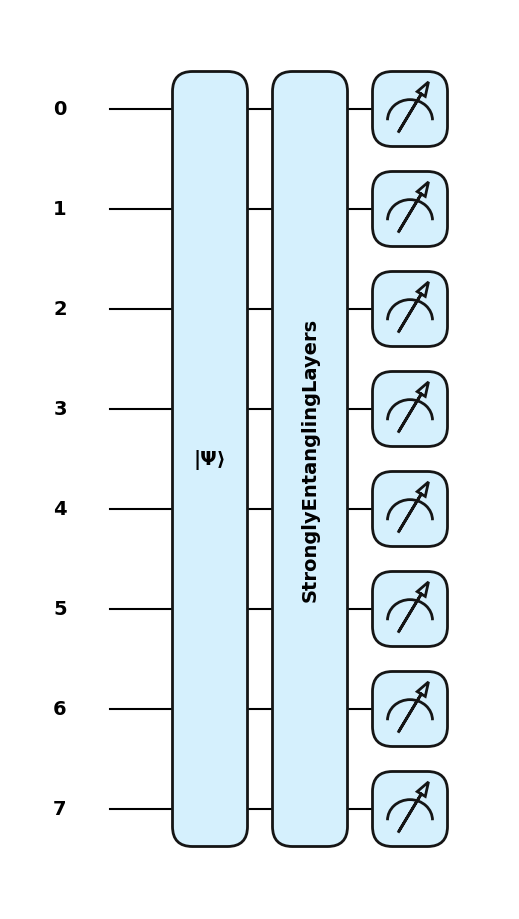

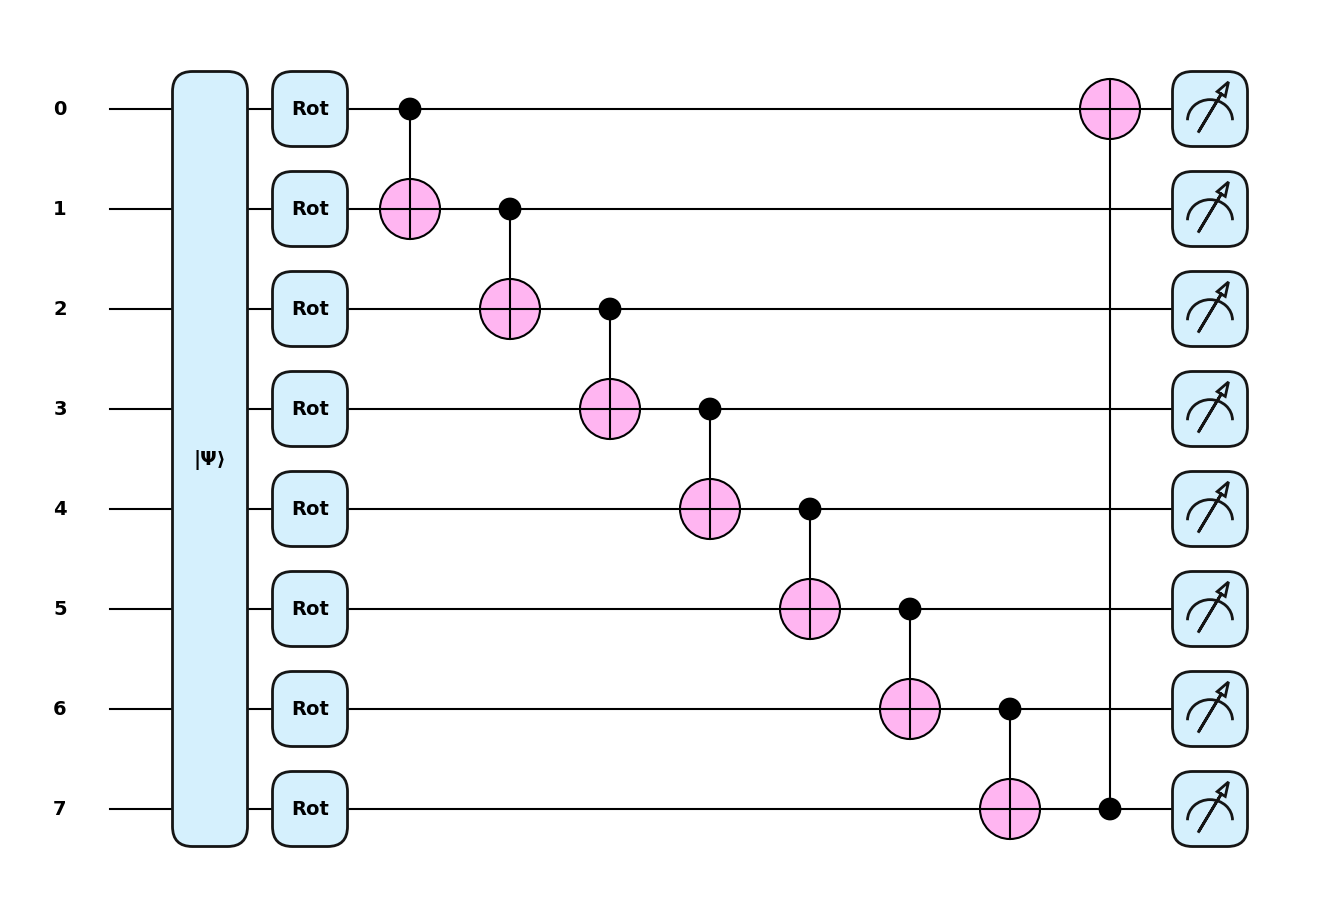

In [3]:
dev = qml.device("default.qubit", wires=8)
n_layers = 1

# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 8, 3))

@qml.qnode(dev)
def quantum_feature_embedding(f, phi, interface="torch", diff_method="backprop", cachesize=1000000):
    qml.AmplitudeEmbedding(features=f, wires=range(8), normalize=True, pad_with=0.)

    # Random quantum circuit
    qml.StronglyEntanglingLayers(weights=rand_params, wires=range(8))

    # Measurement producing classical output values
    return qml.state()
    # return [qml.expval(qml.PauliZ(j)) for j in range(4)]

state = quantum_feature_embedding(f=[1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4], phi=rand_params)
print(state.shape)

def quantum_feature_embedding_batch(x_batch, phi, device="cuda"):
    """
    Applies quantum_feature_embedding_single to a batch of inputs.

    Args:
        x_batch (torch.Tensor): (B, D) input batch.
        phi (np.ndarray or torch.Tensor): parameters for RandomLayers.
        device (str): Device to return output on.

    Returns:
        torch.Tensor: Output of shape (B, 2 ** n_qubits)
    """
    outputs = []
    for x in x_batch:
        result = quantum_feature_embedding(x, phi)
        result_tensor = result.real.to(device)
        outputs.append(result_tensor)

    return torch.stack(outputs)

sample = torch.randn(16, 9).to(device)  # Example batch
phi_tensor = torch.tensor(rand_params, dtype=torch.float32)

output = quantum_feature_embedding_batch(sample, phi_tensor)
print(output)

class quantum_feature_embedding_batch(nn.Module):
    def __init__(self, device="cuda"):
        super().__init__()
        self.phi = nn.Parameter(torch.tensor(np.random.uniform(high=2 * np.pi, size=(n_layers, 3)), dtype=torch.float32))
    
    def forward(self, x_batch):
        phi = self.phi
        outputs = []
        for x in x_batch:
            result = quantum_feature_embedding(x, phi)
            result_tensor = result.real.to(device)
            outputs.append(result_tensor)
    
        return torch.stack(outputs)


qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(quantum_feature_embedding)(f=[1/4]*9, phi=rand_params)
fig, ax = qml.draw_mpl(quantum_feature_embedding, level="device")(f=[1/4]*9, phi=rand_params)

In [4]:
# Generator with Quantum Layer
class Generator(nn.Module):
    def __init__(self, latent_dim=9):
        super().__init__()

        self.noise = GaussianNoise(sigma=0.1)

        self.eps_relu = eps_relu(epsilon = 1e-3)
        
        self.feature_gen = quantum_feature_embedding_batch()

        self.image_gen1 = nn.Sequential(
            self.noise,
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )

        self.image_gen4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid(),
            # self.eps_relu
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat).float()
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen1(img)
        # print(img.shape)
        img = self.image_gen2(img)
        # print(img.shape)
        img = self.image_gen3(img)
        # print(img.shape)
        img = self.image_gen4(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 128

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
   
    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

Image shape: torch.Size([43633, 16, 16])
dR Mean: torch.Size([43633])
dR STD: torch.Size([43633])
Pixel Mean: torch.Size([43633])
Pixel STD: torch.Size([43633])
ΔR min: 0.0
ΔR max: 2.265674114227295
ΔR mean min: 0.0042752958834171295
ΔR mean max: 0.01479329913854599
ΔR std min: 0.02181866206228733
ΔR std max: 0.14948226511478424
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0029057813808321953
Pixel mean max: 0.004424060694873333
Pixel std min: 0.009593216702342033
Pixel std max: 0.06260580569505692


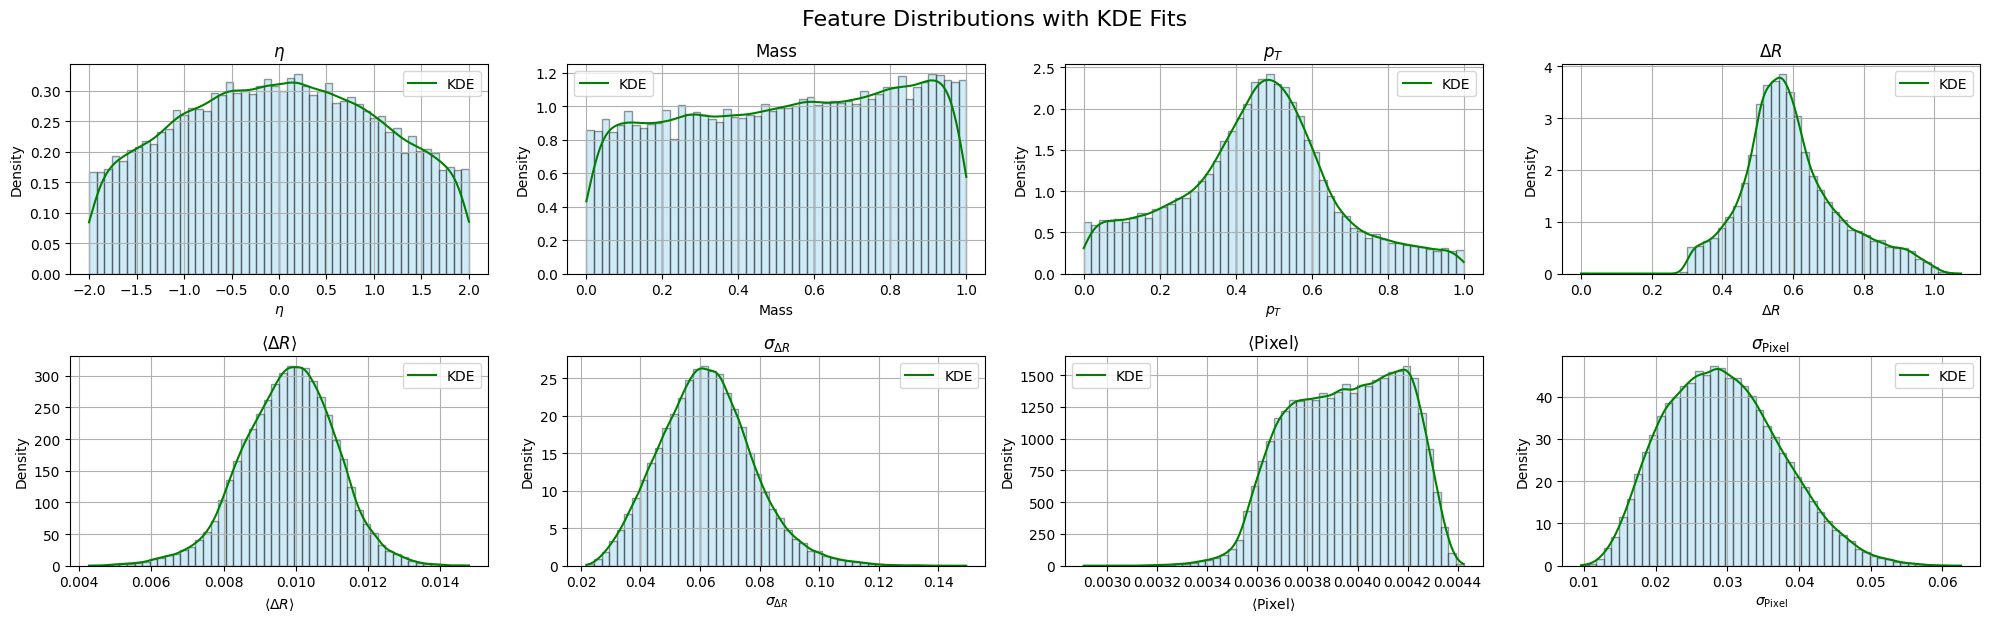

Number of samples: 43633
Image shape: torch.Size([43633, 16, 16])
Feature shape: torch.Size([43633, 9])


In [5]:
batch_size = 128
n_events = int(.05 * jet_mass_data['image'].shape[0])

latent_dim = 256
lr = 1e-3
n_epochs = 300
num = 4

dataset = JetDataset(jet_mass_data, n_events)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

kdes = feature_distributions(dataset)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

In [6]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))

scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

dists = compute_distance_map(16,16).to(device)

In [7]:
g_losses = []
d_losses = []

# Tracking buffers
stats_dict = {
    'fake_dR_mean': [],
    'fake_dR_std': [],
    'fake_pixel_mean': [],
    'fake_pixel_std': [],
    'real_dR_mean': [],
    'real_dR_std': [],
    'real_pixel_mean': [],
    'real_pixel_std': []
}

## Load a previous model
# Replace with the desired filename
load = True

if load:
    load_path = "models/1_layer_Fully_connected_QGAN_works_really_well_m21_1013.pt"
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    # stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/1_layer_Fully_connected_QGAN_m18_1820.pt


[Epoch 1/300] [D loss: 0.7043] [G loss: 12.0706] [Validity_loss: 0.3080] 
 [Stat_loss: 11.7614] [NNZ_loss: 0.0011]
Sample feature coding: [0.         0.6855168  0.2704986  0.73533    0.55119723 0.01135121
 0.06360135 0.00359753 0.04643595]


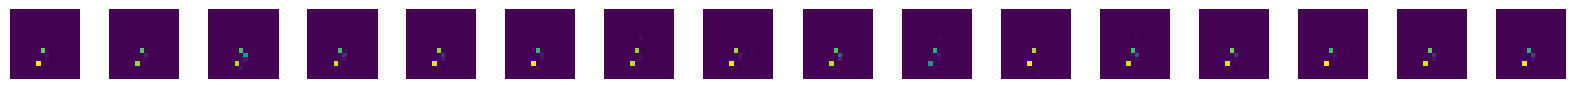

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 2/300] [D loss: 0.6686] [G loss: 1.7256] [Validity_loss: 0.2875] 
 [Stat_loss: 1.4368] [NNZ_loss: 0.0013]
Sample feature coding: [ 1.         -0.01829544  0.9478453   0.13005002  0.66000354  0.00921293
  0.03643969  0.00377706  0.0243555 ]


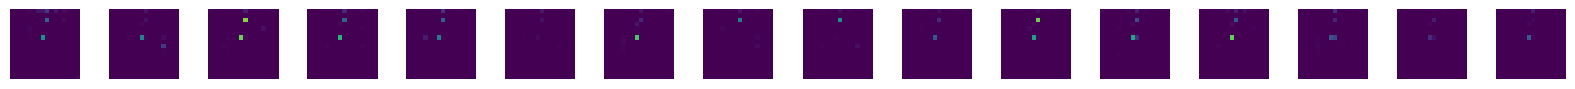

[Epoch 3/300] [D loss: 0.8043] [G loss: 19.5720] [Validity_loss: 0.5746] 
 [Stat_loss: 18.9942] [NNZ_loss: 0.0031]
Sample feature coding: [0.         0.08200397 0.57069016 0.45520002 0.8882124  0.00877561
 0.03694532 0.0038117  0.02820126]


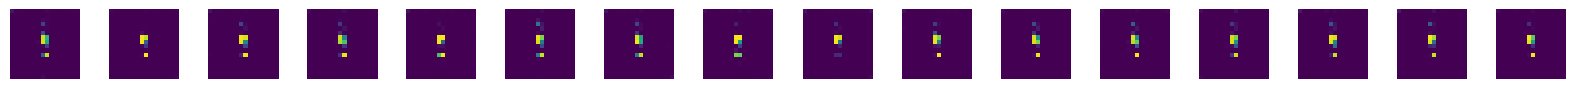

[Epoch 4/300] [D loss: 0.6747] [G loss: 0.3217] [Validity_loss: 0.3160] 
 [Stat_loss: 0.0042] [NNZ_loss: 0.0014]
Sample feature coding: [1.         1.0619885  0.8339143  0.38801196 0.51592493 0.00950931
 0.07955951 0.00396304 0.02338559]


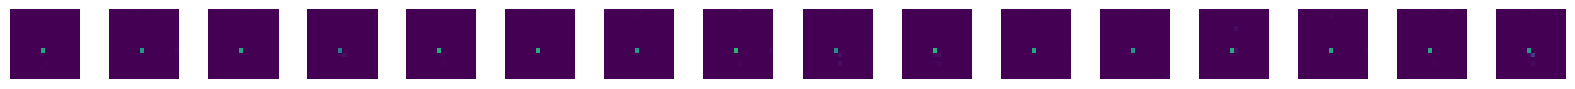

[Epoch 5/300] [D loss: 0.6632] [G loss: 0.2949] [Validity_loss: 0.2860] 
 [Stat_loss: 0.0072] [NNZ_loss: 0.0017]
Sample feature coding: [1.         0.1371795  0.21037546 0.49977735 0.503945   0.01292869
 0.06159902 0.0038476  0.03166719]


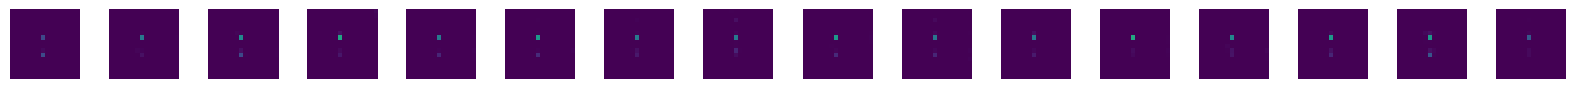

[Epoch 6/300] [D loss: 0.6810] [G loss: 0.3240] [Validity_loss: 0.3221] 
 [Stat_loss: 0.0008] [NNZ_loss: 0.0012]
Sample feature coding: [ 0.         -0.1388843   0.3760094   0.70477027  0.3840449   0.01149785
  0.06659723  0.00387163  0.03754273]


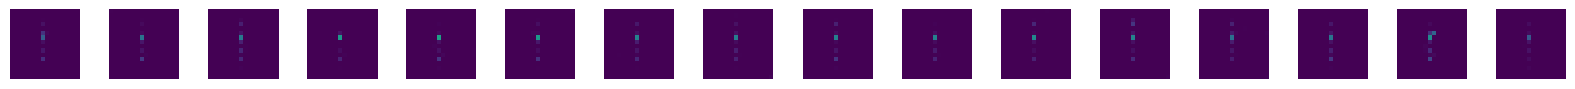

[Epoch 7/300] [D loss: 0.6788] [G loss: 0.3741] [Validity_loss: 0.3326] 
 [Stat_loss: 0.0403] [NNZ_loss: 0.0012]
Sample feature coding: [0.         1.6659169  0.96288276 0.31645358 0.7340153  0.01038588
 0.09461548 0.00403903 0.02564219]


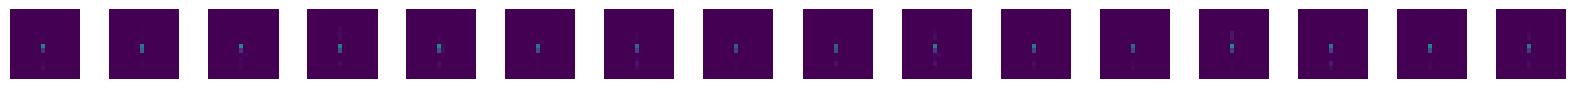

[Epoch 8/300] [D loss: 0.6159] [G loss: 0.3715] [Validity_loss: 0.3632] 
 [Stat_loss: 0.0066] [NNZ_loss: 0.0017]
Sample feature coding: [1.         0.41144186 0.47579652 0.6843012  0.51452374 0.00693658
 0.06200728 0.00404893 0.01915076]


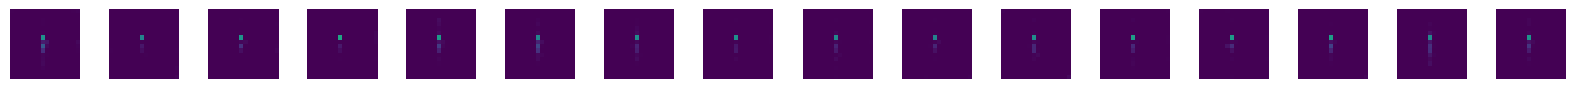

[Epoch 9/300] [D loss: 0.6955] [G loss: 0.3225] [Validity_loss: 0.3196] 
 [Stat_loss: 0.0016] [NNZ_loss: 0.0013]
Sample feature coding: [ 0.         -0.17958064  0.49774125  0.09826485  0.5841533   0.00636824
  0.08462965  0.00367832  0.02561018]


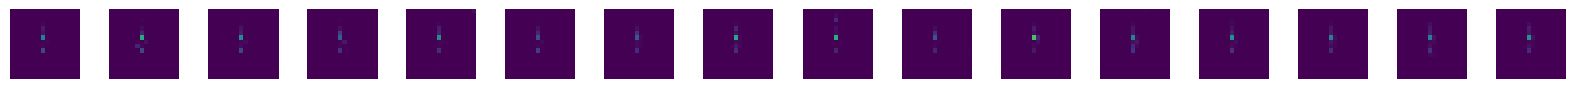

[Epoch 10/300] [D loss: 0.6332] [G loss: 0.3626] [Validity_loss: 0.3563] 
 [Stat_loss: 0.0051] [NNZ_loss: 0.0012]
Sample feature coding: [0.         1.8609899  0.71033424 0.7407616  0.6138243  0.00805678
 0.05060462 0.00384087 0.02503974]


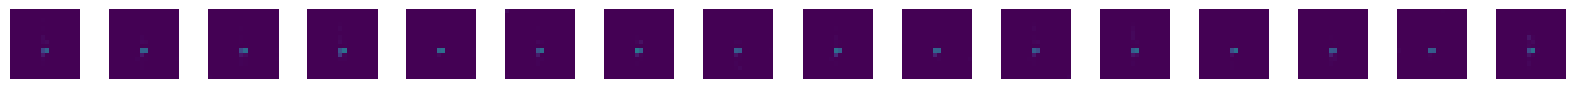

[Epoch 11/300] [D loss: 0.6275] [G loss: 0.3603] [Validity_loss: 0.3316] 
 [Stat_loss: 0.0274] [NNZ_loss: 0.0014]
Sample feature coding: [1.         0.42855045 0.6852336  0.4806609  0.42679673 0.01081425
 0.05448576 0.00416464 0.03551446]


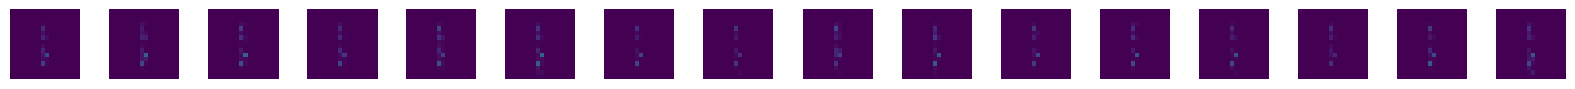

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 12/300] [D loss: 0.6631] [G loss: 0.3425] [Validity_loss: 0.3279] 
 [Stat_loss: 0.0134] [NNZ_loss: 0.0012]
Sample feature coding: [ 0.         -1.1857581   0.34034643  0.36229092  0.54586506  0.01104903
  0.05460402  0.00420477  0.02888204]


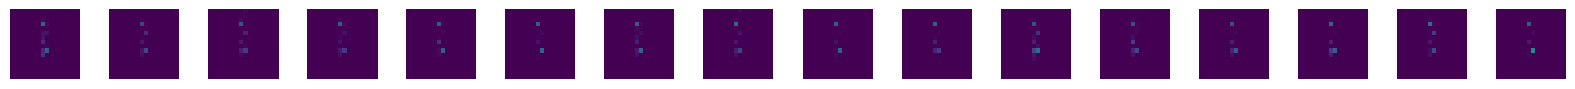

[Epoch 13/300] [D loss: 0.6168] [G loss: 0.7222] [Validity_loss: 0.4362] 
 [Stat_loss: 0.2837] [NNZ_loss: 0.0023]
Sample feature coding: [0.         1.1471112  0.64153516 0.46695834 0.91699255 0.00963633
 0.05836055 0.004026   0.01560119]


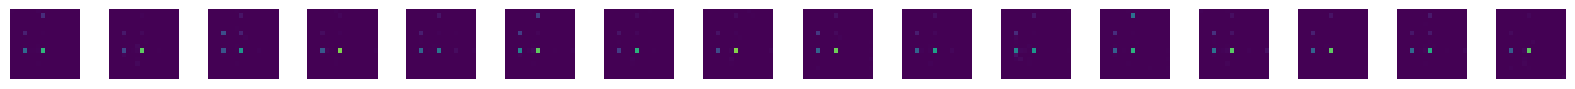

[Epoch 14/300] [D loss: 0.5478] [G loss: 0.4344] [Validity_loss: 0.4299] 
 [Stat_loss: 0.0030] [NNZ_loss: 0.0016]
Sample feature coding: [ 1.         -1.8468088   0.30405396  0.4649529   0.48385134  0.01082752
  0.05629664  0.00363282  0.03696279]


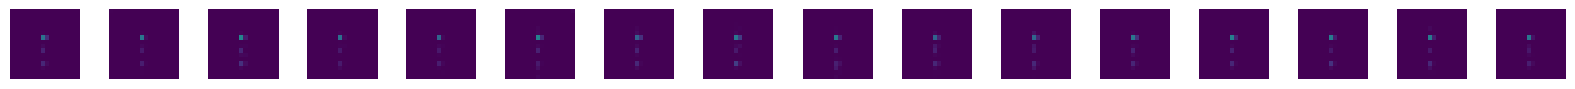

[Epoch 15/300] [D loss: 0.6427] [G loss: 0.7800] [Validity_loss: 0.3808] 
 [Stat_loss: 0.3978] [NNZ_loss: 0.0014]
Sample feature coding: [ 1.         -0.61400694  0.18640336  1.0103666   0.44702473  0.01134276
  0.05851258  0.00382072  0.03821842]


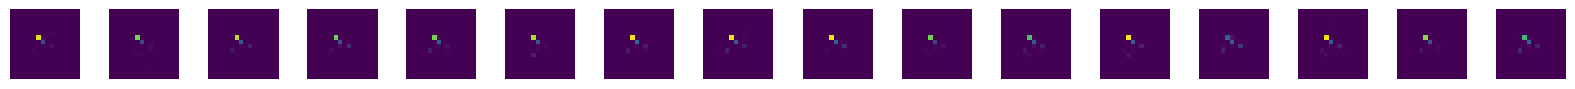

[Epoch 16/300] [D loss: 0.6839] [G loss: 0.3549] [Validity_loss: 0.3454] 
 [Stat_loss: 0.0085] [NNZ_loss: 0.0011]
Sample feature coding: [ 1.         -0.13563266  0.62073165  0.22032127  0.41247305  0.01070683
  0.05808733  0.00420067  0.02574625]


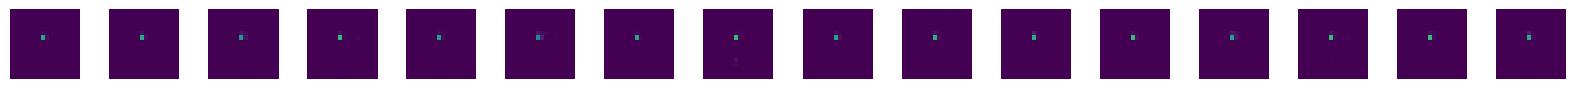

[Epoch 17/300] [D loss: 0.6488] [G loss: 0.3297] [Validity_loss: 0.3277] 
 [Stat_loss: 0.0006] [NNZ_loss: 0.0014]
Sample feature coding: [1.         1.1127207  0.81373984 0.44971278 0.6762647  0.00894839
 0.0723689  0.00341056 0.03486976]


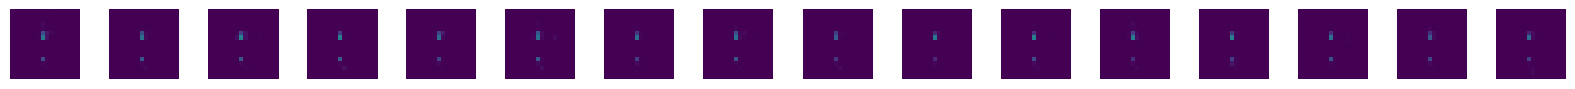

[Epoch 18/300] [D loss: 0.6476] [G loss: 0.3851] [Validity_loss: 0.3277] 
 [Stat_loss: 0.0562] [NNZ_loss: 0.0013]
Sample feature coding: [ 1.         -1.9693888   0.0866359   1.0004907   0.6902773   0.01186911
  0.07824889  0.00374733  0.03670338]


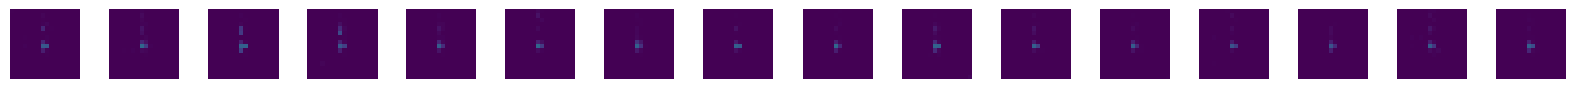

[Epoch 19/300] [D loss: 0.6733] [G loss: 0.3156] [Validity_loss: 0.3007] 
 [Stat_loss: 0.0140] [NNZ_loss: 0.0009]
Sample feature coding: [ 1.         -0.34779587  0.21687546  0.2711471   0.5811211   0.00995468
  0.05821601  0.00427329  0.02300892]


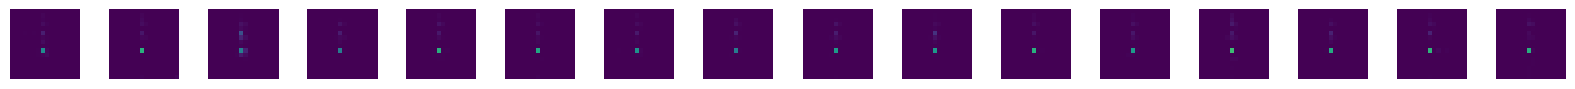

[Epoch 20/300] [D loss: 0.6226] [G loss: 0.4517] [Validity_loss: 0.3535] 
 [Stat_loss: 0.0970] [NNZ_loss: 0.0011]
Sample feature coding: [0.         1.744915   0.1916614  0.55613166 0.5829767  0.01088233
 0.08049557 0.00397033 0.03013032]


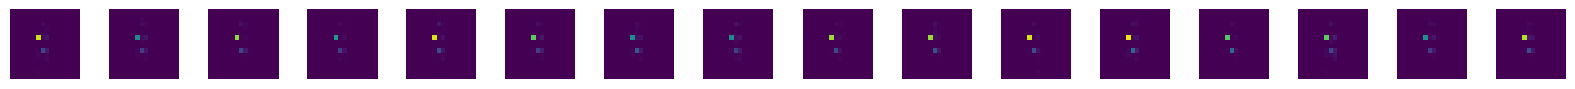

[Epoch 21/300] [D loss: 0.6383] [G loss: 0.3442] [Validity_loss: 0.3365] 
 [Stat_loss: 0.0067] [NNZ_loss: 0.0010]
Sample feature coding: [1.         1.315595   0.97334915 0.2788758  0.41429782 0.00794388
 0.03886091 0.0041829  0.02237332]


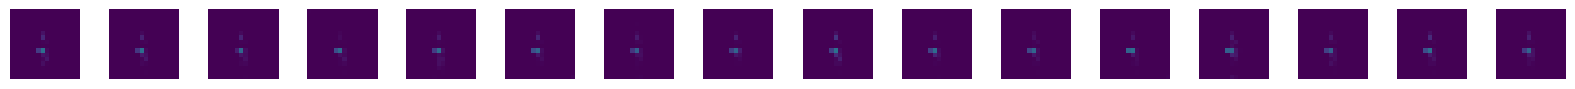

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 22/300] [D loss: 0.6502] [G loss: 1.3330] [Validity_loss: 0.3404] 
 [Stat_loss: 0.9917] [NNZ_loss: 0.0009]
Sample feature coding: [ 0.         -1.393186    0.21253817  0.2282824   0.7326961   0.01014668
  0.09772924  0.00390438  0.02180013]


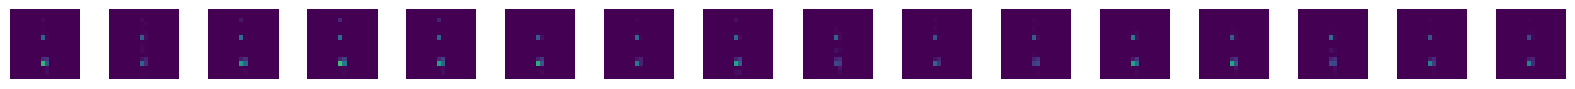

[Epoch 23/300] [D loss: 0.6687] [G loss: 0.3822] [Validity_loss: 0.3501] 
 [Stat_loss: 0.0311] [NNZ_loss: 0.0011]
Sample feature coding: [1.         0.13309504 0.02876367 0.39556628 0.5010907  0.00975258
 0.06140611 0.00398509 0.03220029]


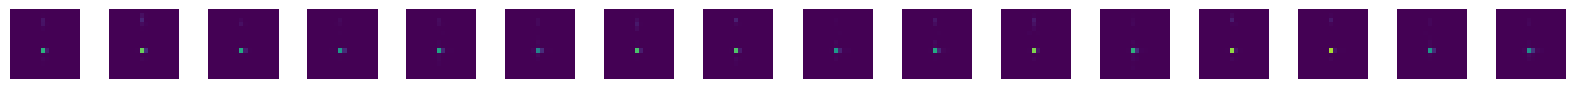

[Epoch 24/300] [D loss: 0.6466] [G loss: 0.3790] [Validity_loss: 0.3375] 
 [Stat_loss: 0.0404] [NNZ_loss: 0.0010]
Sample feature coding: [1.         1.0369413  0.26302707 0.44481567 0.8155475  0.01064507
 0.05018533 0.00382927 0.02208724]


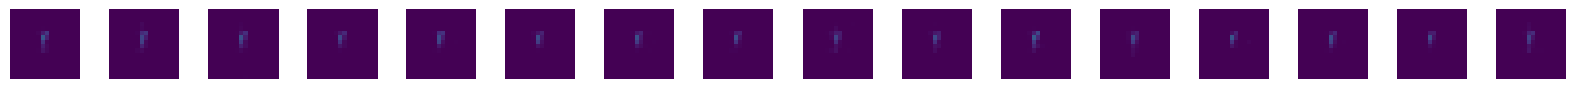

[Epoch 25/300] [D loss: 0.7098] [G loss: 0.3543] [Validity_loss: 0.3294] 
 [Stat_loss: 0.0236] [NNZ_loss: 0.0012]
Sample feature coding: [ 0.         -0.2493294   0.8566939   0.33849993  0.5248562   0.00912374
  0.05366494  0.00379504  0.03745494]


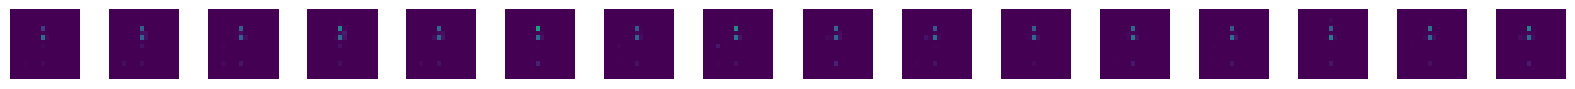

[Epoch 26/300] [D loss: 0.6652] [G loss: 0.8013] [Validity_loss: 0.3113] 
 [Stat_loss: 0.4891] [NNZ_loss: 0.0010]
Sample feature coding: [0.         1.7543377  0.8644265  0.3216244  0.5765464  0.01073164
 0.05032789 0.00382817 0.02031681]


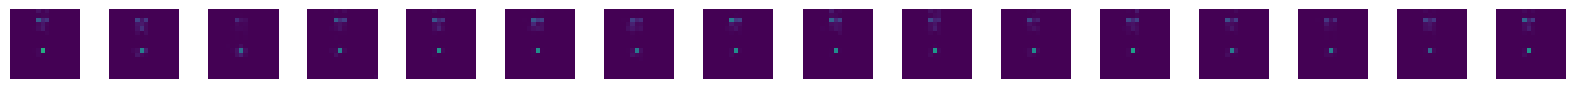

[Epoch 27/300] [D loss: 0.4742] [G loss: 0.5493] [Validity_loss: 0.5261] 
 [Stat_loss: 0.0214] [NNZ_loss: 0.0019]
Sample feature coding: [0.         1.3597198  1.0113484  0.65779555 0.60540044 0.00912131
 0.05688124 0.00398604 0.02217439]


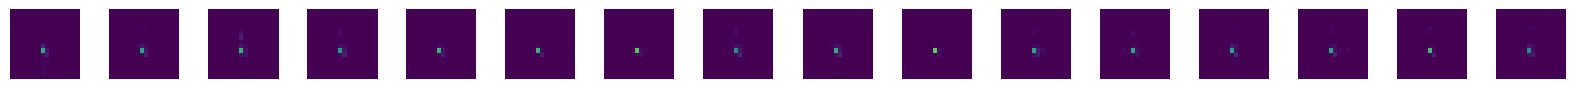

[Epoch 28/300] [D loss: 0.7743] [G loss: 0.4525] [Validity_loss: 0.2605] 
 [Stat_loss: 0.1896] [NNZ_loss: 0.0023]
Sample feature coding: [0.         1.1744001  0.4716432  0.4001709  0.439212   0.01112639
 0.05634607 0.00397778 0.01892642]


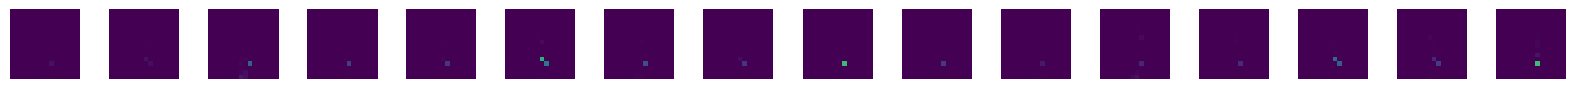

[Epoch 29/300] [D loss: 0.7230] [G loss: 0.6335] [Validity_loss: 0.2879] 
 [Stat_loss: 0.3437] [NNZ_loss: 0.0019]
Sample feature coding: [ 0.         -0.29137713  0.85012627 -0.00302124  0.55709666  0.00986276
  0.07186048  0.003663    0.02862573]


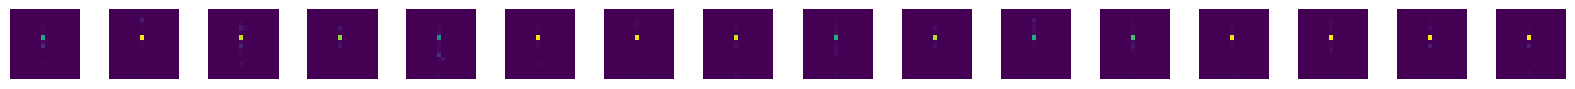

[Epoch 30/300] [D loss: 0.6398] [G loss: 0.3805] [Validity_loss: 0.3518] 
 [Stat_loss: 0.0270] [NNZ_loss: 0.0017]
Sample feature coding: [1.         0.92437196 0.94959533 0.3947937  0.66529065 0.01104652
 0.06342506 0.0040802  0.04895931]


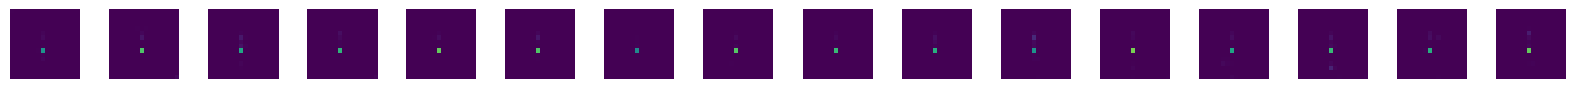

[Epoch 31/300] [D loss: 0.6165] [G loss: 0.3878] [Validity_loss: 0.3649] 
 [Stat_loss: 0.0215] [NNZ_loss: 0.0014]
Sample feature coding: [ 1.         -0.20363806  0.57115877  0.08681579  0.5225253   0.01015505
  0.06885904  0.00382993  0.0262198 ]


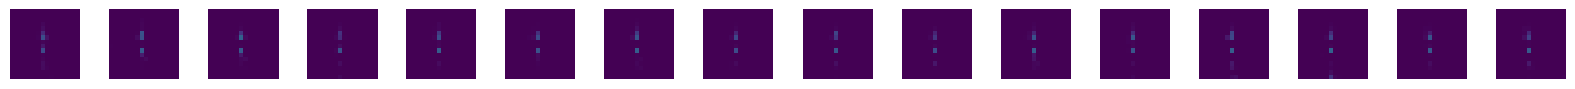

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 32/300] [D loss: 0.6136] [G loss: 0.3881] [Validity_loss: 0.3664] 
 [Stat_loss: 0.0205] [NNZ_loss: 0.0013]
Sample feature coding: [ 1.         -0.31741935  0.49449858  0.56883925  0.55772156  0.01001143
  0.05189947  0.00398719  0.04172533]


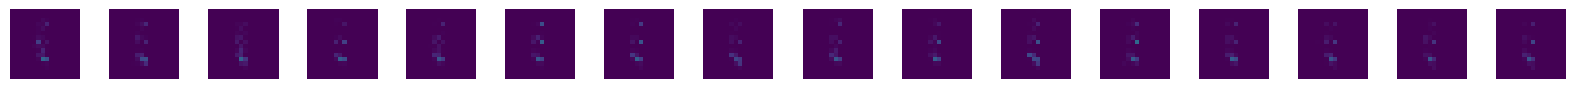

[Epoch 33/300] [D loss: 0.6822] [G loss: 0.4004] [Validity_loss: 0.3922] 
 [Stat_loss: 0.0066] [NNZ_loss: 0.0016]
Sample feature coding: [1.         2.007212   0.9712459  0.51118207 0.6657087  0.00677755
 0.04689052 0.00408077 0.04007273]


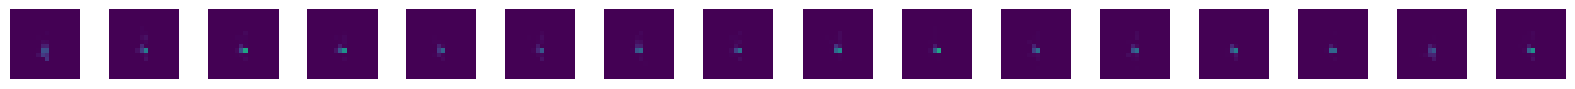

[Epoch 34/300] [D loss: 0.7021] [G loss: 0.3344] [Validity_loss: 0.3161] 
 [Stat_loss: 0.0170] [NNZ_loss: 0.0012]
Sample feature coding: [0.         1.8470563  0.11690711 0.45493346 0.42673522 0.01073737
 0.04481412 0.00388451 0.05100327]


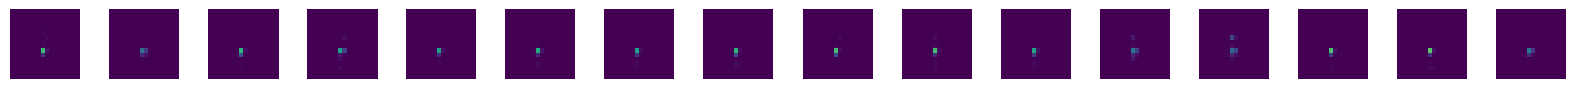

[Epoch 35/300] [D loss: 0.6741] [G loss: 0.3399] [Validity_loss: 0.3358] 
 [Stat_loss: 0.0025] [NNZ_loss: 0.0016]
Sample feature coding: [0.         0.5389506  0.59499365 0.37055957 0.60470617 0.00889045
 0.05624932 0.0042312  0.02166142]


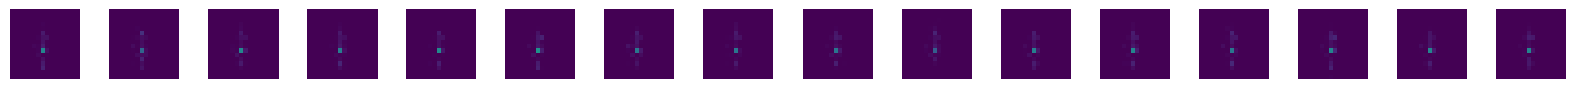

[Epoch 36/300] [D loss: 0.5578] [G loss: 0.4079] [Validity_loss: 0.3901] 
 [Stat_loss: 0.0155] [NNZ_loss: 0.0023]
Sample feature coding: [0.         0.99561447 0.12794553 0.46304533 0.5489889  0.00896914
 0.0543906  0.00414339 0.02569648]


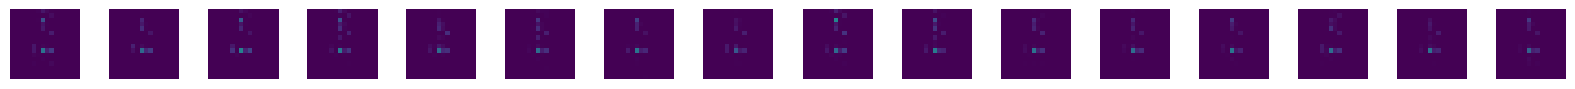

[Epoch 37/300] [D loss: 0.6413] [G loss: 0.5104] [Validity_loss: 0.3453] 
 [Stat_loss: 0.1636] [NNZ_loss: 0.0015]
Sample feature coding: [0.         0.83328    0.51523226 0.40625998 0.6010971  0.00911384
 0.08978879 0.00425316 0.02913004]


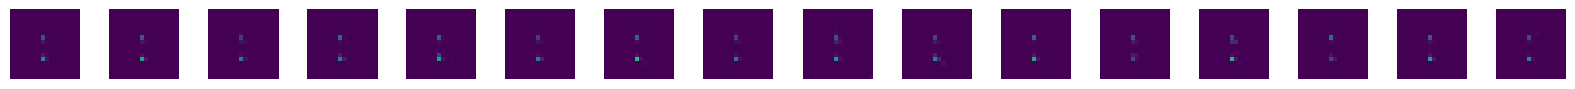

[Epoch 38/300] [D loss: 0.7315] [G loss: 1.6176] [Validity_loss: 0.3718] 
 [Stat_loss: 1.2445] [NNZ_loss: 0.0013]
Sample feature coding: [ 0.         -0.20455189  0.64385104  0.6191287   0.5030304   0.00968162
  0.03748811  0.00421071  0.01387595]


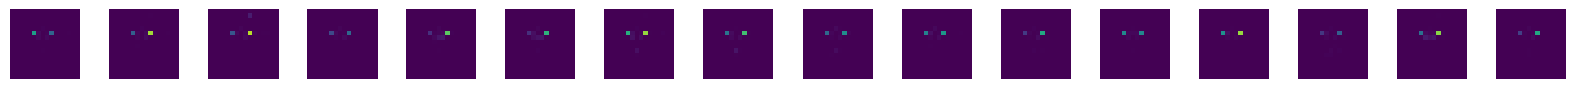

[Epoch 39/300] [D loss: 0.6453] [G loss: 0.5173] [Validity_loss: 0.3490] 
 [Stat_loss: 0.1662] [NNZ_loss: 0.0021]
Sample feature coding: [ 0.         -1.3170853   0.829289    0.37310582  0.56120557  0.00802294
  0.06063588  0.00386806  0.03075884]


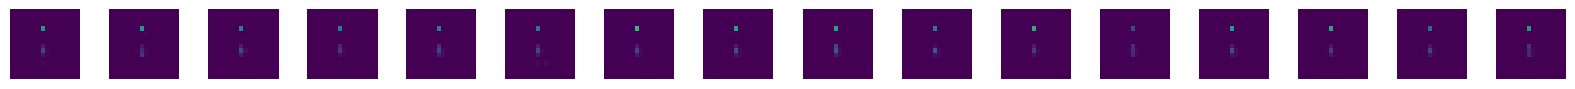

[Epoch 40/300] [D loss: 0.6521] [G loss: 0.4672] [Validity_loss: 0.3858] 
 [Stat_loss: 0.0797] [NNZ_loss: 0.0017]
Sample feature coding: [0.         0.4461531  0.9035931  0.4821689  0.5278977  0.00887031
 0.06116625 0.00387639 0.01987243]


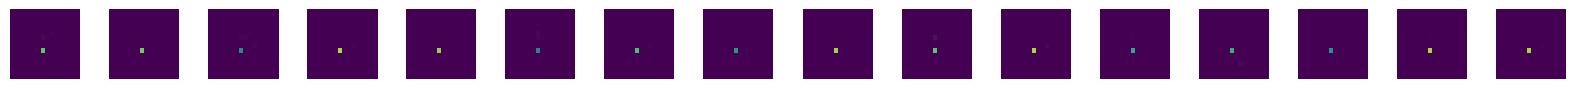

[Epoch 41/300] [D loss: 0.5696] [G loss: 0.3539] [Validity_loss: 0.3501] 
 [Stat_loss: 0.0024] [NNZ_loss: 0.0013]
Sample feature coding: [0.         1.8264437  0.5125079  0.50724393 0.49850965 0.01187818
 0.06720367 0.00411573 0.03183345]


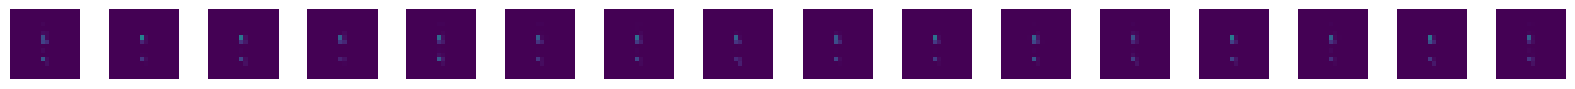

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 42/300] [D loss: 0.7374] [G loss: 0.3469] [Validity_loss: 0.3154] 
 [Stat_loss: 0.0288] [NNZ_loss: 0.0027]
Sample feature coding: [0.         0.39596495 0.547557   0.5088186  0.36507663 0.0100901
 0.0644994  0.00392595 0.03650191]


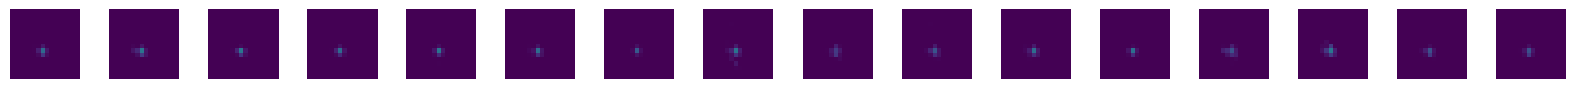

[Epoch 43/300] [D loss: 0.6221] [G loss: 2.1352] [Validity_loss: 0.3492] 
 [Stat_loss: 1.7843] [NNZ_loss: 0.0016]
Sample feature coding: [ 1.         -0.09283032  0.4022992   0.47910458  0.61829317  0.01063969
  0.07094766  0.00412176  0.0379981 ]


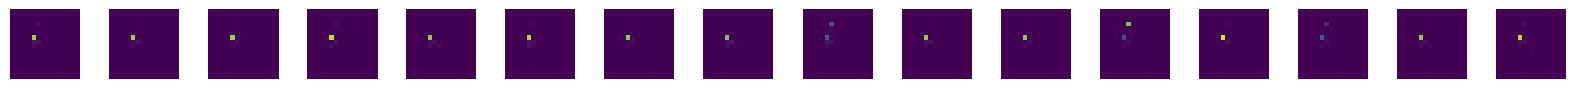

[Epoch 44/300] [D loss: 0.6050] [G loss: 8.8448] [Validity_loss: 0.5427] 
 [Stat_loss: 8.3007] [NNZ_loss: 0.0014]
Sample feature coding: [1.         0.44476256 0.13283445 0.32419953 0.32004845 0.00881775
 0.06498868 0.00402534 0.04051102]


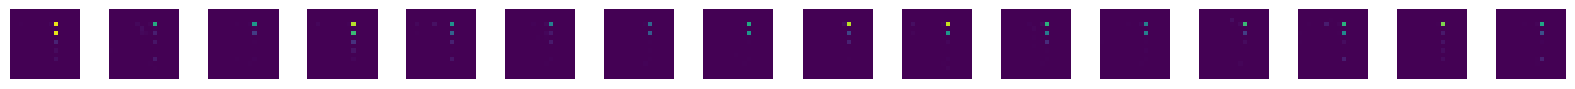

[Epoch 45/300] [D loss: 0.5247] [G loss: 0.4088] [Validity_loss: 0.3839] 
 [Stat_loss: 0.0234] [NNZ_loss: 0.0015]
Sample feature coding: [1.         0.42062747 0.46800143 0.4764751  0.64702946 0.01089508
 0.07412402 0.00371363 0.01979437]


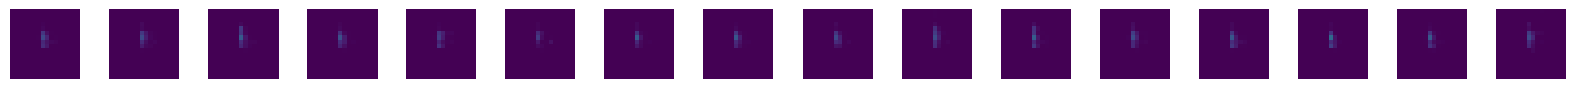

[Epoch 46/300] [D loss: 0.5910] [G loss: 0.4202] [Validity_loss: 0.3915] 
 [Stat_loss: 0.0256] [NNZ_loss: 0.0032]
Sample feature coding: [ 1.         -0.84087807  0.12451105  0.5667308   0.43368673  0.00967229
  0.06705387  0.00402682  0.0444883 ]


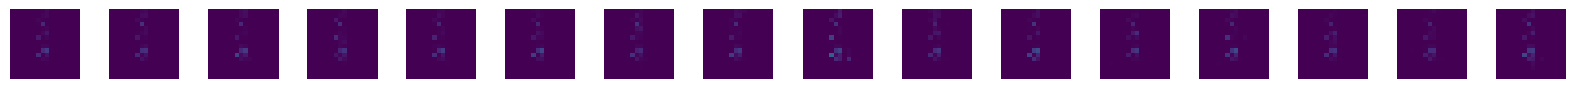

[Epoch 47/300] [D loss: 0.5772] [G loss: 0.3843] [Validity_loss: 0.3698] 
 [Stat_loss: 0.0130] [NNZ_loss: 0.0015]
Sample feature coding: [1.         0.30262858 0.7421794  0.2985843  0.6470094  0.01100952
 0.06299767 0.00403469 0.02483267]


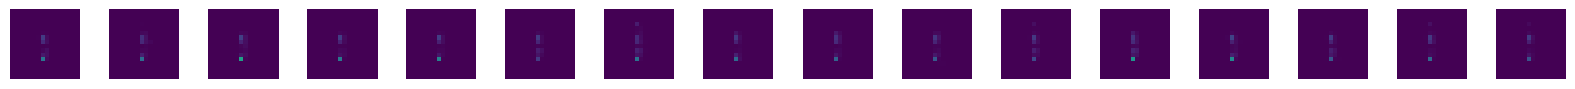

[Epoch 48/300] [D loss: 0.5099] [G loss: 0.4749] [Validity_loss: 0.4696] 
 [Stat_loss: 0.0040] [NNZ_loss: 0.0013]
Sample feature coding: [ 0.         -0.20694906  0.3656814   0.6785361   0.45490995  0.01325031
  0.07182931  0.0041627   0.0209893 ]


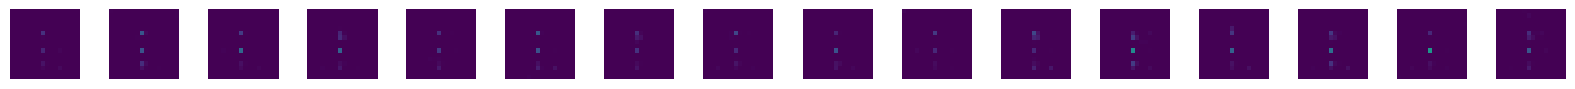

[Epoch 49/300] [D loss: 0.9518] [G loss: 0.4582] [Validity_loss: 0.4553] 
 [Stat_loss: 0.0018] [NNZ_loss: 0.0010]
Sample feature coding: [1.         1.8021706  0.5095982  0.2411164  0.71072197 0.01020682
 0.06426568 0.00368267 0.02887112]


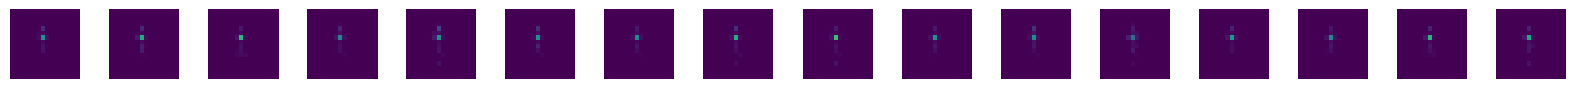

[Epoch 50/300] [D loss: 0.4300] [G loss: 0.5126] [Validity_loss: 0.4659] 
 [Stat_loss: 0.0457] [NNZ_loss: 0.0010]
Sample feature coding: [ 1.         -0.5779233   0.8473093   0.0766515   0.52434325  0.01109846
  0.04090394  0.00413765  0.03394369]


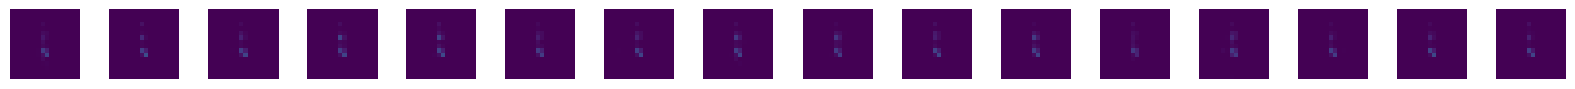

[Epoch 51/300] [D loss: 0.3785] [G loss: 0.6145] [Validity_loss: 0.5934] 
 [Stat_loss: 0.0198] [NNZ_loss: 0.0013]
Sample feature coding: [ 1.         -0.2732773   0.20204836  0.04315733  0.5313195   0.00930957
  0.06967377  0.00375063  0.02437672]


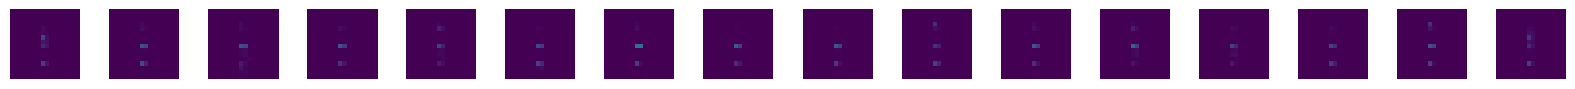

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 52/300] [D loss: 0.5673] [G loss: 0.4067] [Validity_loss: 0.4052] 
 [Stat_loss: 0.0002] [NNZ_loss: 0.0013]
Sample feature coding: [0.         0.81786805 0.6699862  0.4098279  0.5998145  0.01027006
 0.05799665 0.00386675 0.02848976]


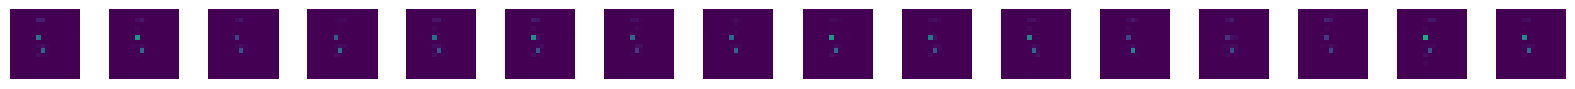

[Epoch 53/300] [D loss: 0.6184] [G loss: 0.3933] [Validity_loss: 0.3197] 
 [Stat_loss: 0.0668] [NNZ_loss: 0.0067]
Sample feature coding: [1.         1.0217319  0.40627384 0.00633228 0.8214052  0.01019986
 0.0553141  0.00419229 0.02205495]


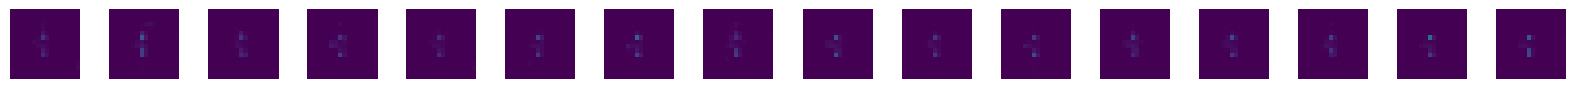

[Epoch 54/300] [D loss: 0.4853] [G loss: 0.5015] [Validity_loss: 0.4764] 
 [Stat_loss: 0.0234] [NNZ_loss: 0.0018]
Sample feature coding: [ 1.         -0.66765285  0.93188506  0.662521    0.7573114   0.00818798
  0.04950997  0.00393211  0.04201107]


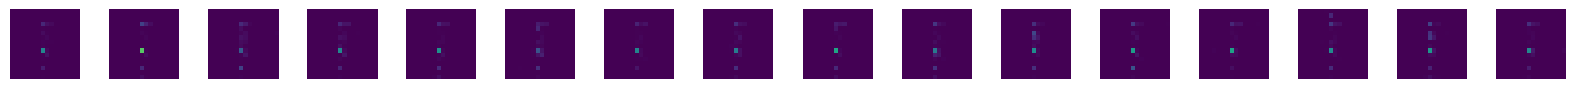

[Epoch 55/300] [D loss: 0.5512] [G loss: 0.4270] [Validity_loss: 0.3958] 
 [Stat_loss: 0.0293] [NNZ_loss: 0.0019]
Sample feature coding: [ 0.         -1.4450654   0.65393263  0.00716166  0.4661907   0.01137168
  0.0707412   0.00359529  0.02891498]


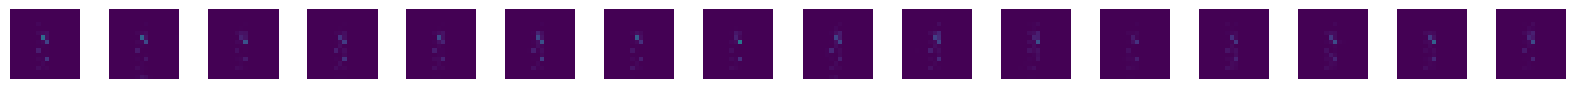

[Epoch 56/300] [D loss: 0.4320] [G loss: 0.5187] [Validity_loss: 0.4638] 
 [Stat_loss: 0.0524] [NNZ_loss: 0.0024]
Sample feature coding: [0.         1.0829751  0.1555576  0.57177836 0.5982772  0.01147715
 0.09663454 0.00366419 0.01792413]


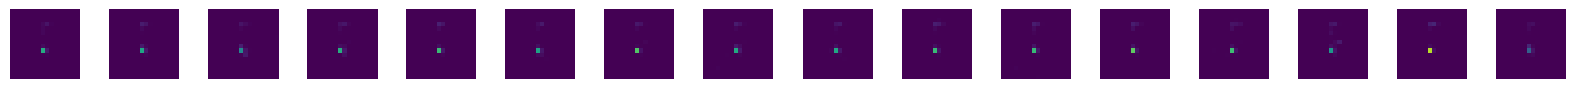

[Epoch 57/300] [D loss: 0.5343] [G loss: 0.3985] [Validity_loss: 0.3931] 
 [Stat_loss: 0.0043] [NNZ_loss: 0.0011]
Sample feature coding: [0.         0.16812646 0.42842036 0.6242391  0.57299423 0.0115833
 0.05154297 0.00391783 0.01779053]


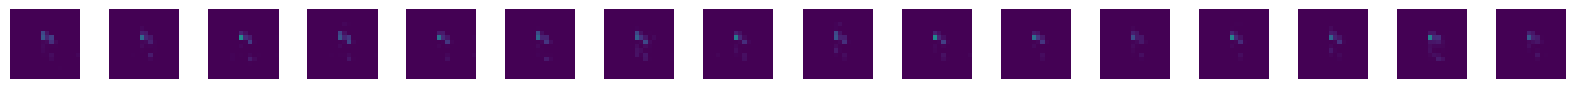

[Epoch 58/300] [D loss: 0.4025] [G loss: 0.5781] [Validity_loss: 0.5365] 
 [Stat_loss: 0.0380] [NNZ_loss: 0.0037]
Sample feature coding: [ 0.         -0.05536067  0.30703086  0.55687314  0.5081488   0.00967517
  0.05368137  0.00393756  0.02173188]


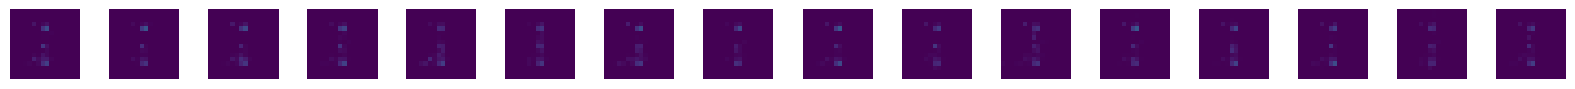

[Epoch 59/300] [D loss: 0.6334] [G loss: 0.2908] [Validity_loss: 0.2839] 
 [Stat_loss: 0.0044] [NNZ_loss: 0.0025]
Sample feature coding: [ 1.         -0.62015784  0.98094904  0.85817945  0.5838008   0.01050427
  0.06534773  0.00376691  0.05377168]


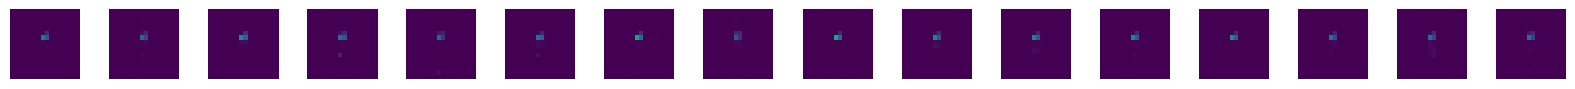

[Epoch 60/300] [D loss: 0.3763] [G loss: 0.6348] [Validity_loss: 0.5777] 
 [Stat_loss: 0.0551] [NNZ_loss: 0.0020]
Sample feature coding: [1.         1.9119055  0.37318346 0.4650931  0.34986404 0.01244654
 0.08153402 0.00398277 0.03047209]


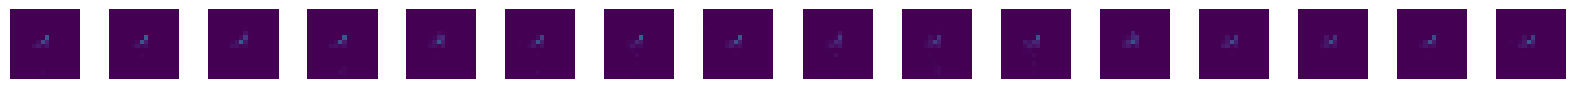

[Epoch 61/300] [D loss: 0.3335] [G loss: 0.5075] [Validity_loss: 0.4998] 
 [Stat_loss: 0.0041] [NNZ_loss: 0.0035]
Sample feature coding: [ 1.         -1.2592537   0.36341822  0.28715032  0.39835915  0.01011951
  0.06091462  0.00392869  0.02977863]


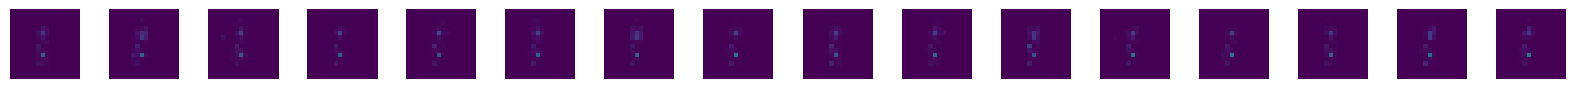

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 62/300] [D loss: 0.5006] [G loss: 0.5557] [Validity_loss: 0.4654] 
 [Stat_loss: 0.0888] [NNZ_loss: 0.0015]
Sample feature coding: [1.         0.3354858  0.3190499  0.46584043 0.5677889  0.00953415
 0.04738759 0.00422387 0.01649894]


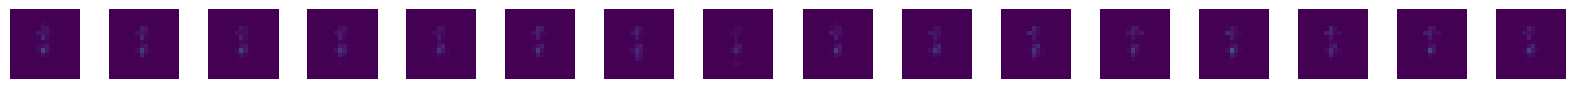

[Epoch 63/300] [D loss: 0.4247] [G loss: 0.4730] [Validity_loss: 0.4671] 
 [Stat_loss: 0.0048] [NNZ_loss: 0.0011]
Sample feature coding: [ 0.         -1.2226224  -0.03125525  0.0831663   0.7414791   0.00818731
  0.05471238  0.00402867  0.0422274 ]


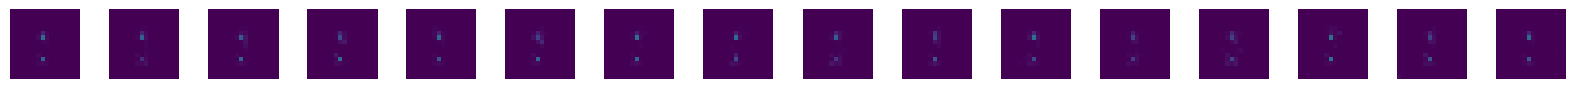

[Epoch 64/300] [D loss: 0.4851] [G loss: 0.6214] [Validity_loss: 0.5813] 
 [Stat_loss: 0.0390] [NNZ_loss: 0.0011]
Sample feature coding: [ 0.         -0.78806585  0.25232738  0.45824313  0.77553093  0.00970353
  0.07930514  0.00381793  0.04034859]


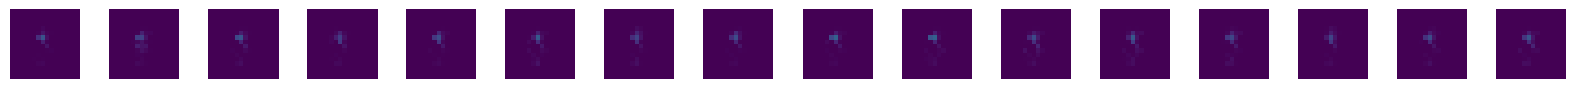

[Epoch 65/300] [D loss: 0.5677] [G loss: 0.6428] [Validity_loss: 0.6285] 
 [Stat_loss: 0.0128] [NNZ_loss: 0.0015]
Sample feature coding: [0.         1.5437037  0.2571201  0.47310993 0.47594273 0.00720134
 0.05372871 0.00388369 0.02239405]


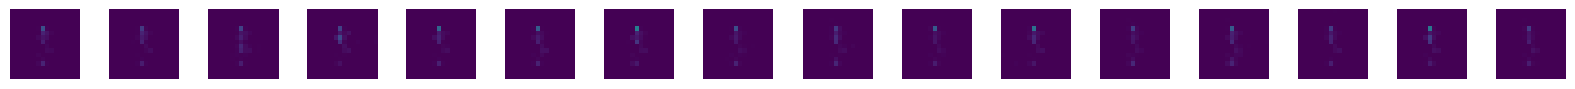

[Epoch 66/300] [D loss: 0.3306] [G loss: 0.8408] [Validity_loss: 0.8351] 
 [Stat_loss: 0.0040] [NNZ_loss: 0.0017]
Sample feature coding: [0.         0.41856754 0.7196211  0.07269196 0.58554465 0.00864392
 0.06755045 0.00415901 0.03222924]


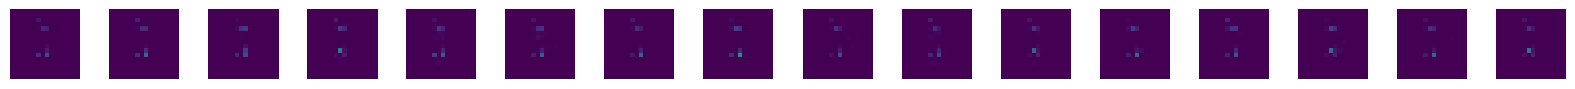

[Epoch 67/300] [D loss: 0.4273] [G loss: 0.4964] [Validity_loss: 0.4935] 
 [Stat_loss: 0.0012] [NNZ_loss: 0.0017]
Sample feature coding: [1.         1.7999549  0.9698675  1.0087568  0.498479   0.00829381
 0.03565168 0.00363722 0.02027714]


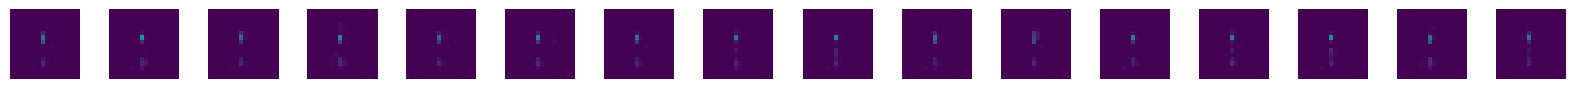

[Epoch 68/300] [D loss: 0.2956] [G loss: 0.7978] [Validity_loss: 0.7779] 
 [Stat_loss: 0.0187] [NNZ_loss: 0.0013]
Sample feature coding: [ 1.         -0.9780014   0.88827765  0.23542851  0.66387993  0.00948882
  0.04976294  0.00366365  0.01808207]


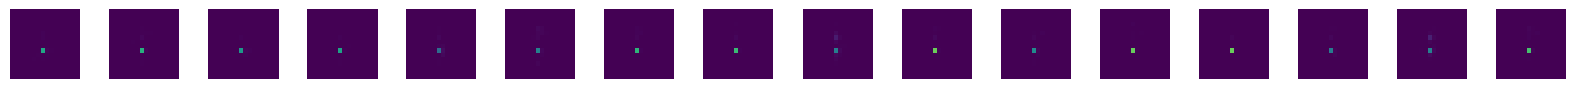

[Epoch 69/300] [D loss: 0.4407] [G loss: 0.5166] [Validity_loss: 0.4913] 
 [Stat_loss: 0.0120] [NNZ_loss: 0.0133]
Sample feature coding: [ 1.         -0.08911038  0.4477579   0.52892023  0.56012094  0.01107413
  0.0947032   0.00378927  0.03702758]


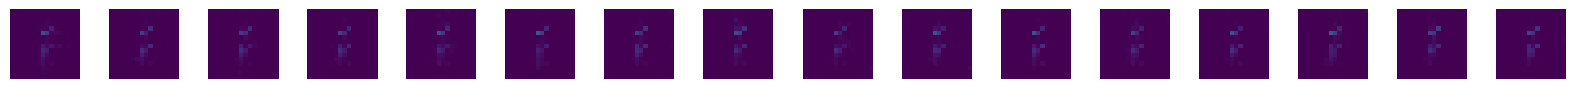

[Epoch 70/300] [D loss: 0.4455] [G loss: 0.5772] [Validity_loss: 0.5623] 
 [Stat_loss: 0.0129] [NNZ_loss: 0.0020]
Sample feature coding: [ 1.         -0.96380806  0.91700524  0.08181967  0.5972064   0.0097488
  0.06083602  0.00372134  0.01723521]


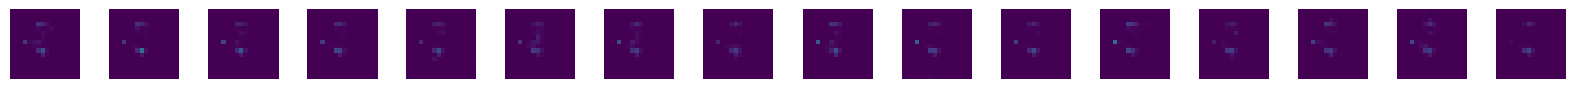

[Epoch 71/300] [D loss: 0.4384] [G loss: 0.5083] [Validity_loss: 0.5022] 
 [Stat_loss: 0.0049] [NNZ_loss: 0.0011]
Sample feature coding: [0.         0.2632443  0.60045373 0.4164727  0.90415925 0.01080201
 0.0658419  0.00404873 0.03647617]


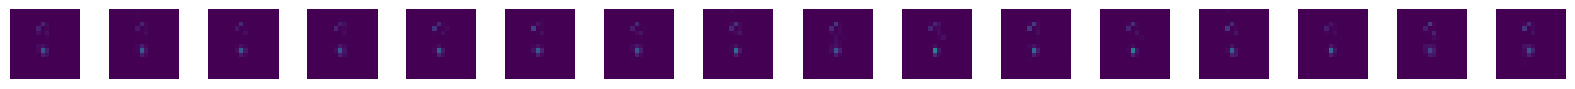

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt
[Epoch 72/300] [D loss: 0.4801] [G loss: 0.6663] [Validity_loss: 0.5975] 
 [Stat_loss: 0.0661] [NNZ_loss: 0.0027]
Sample feature coding: [ 0.         -0.6395904   0.27810928  0.23570076  0.6406035   0.01212895
  0.0691296   0.00418255  0.0212615 ]


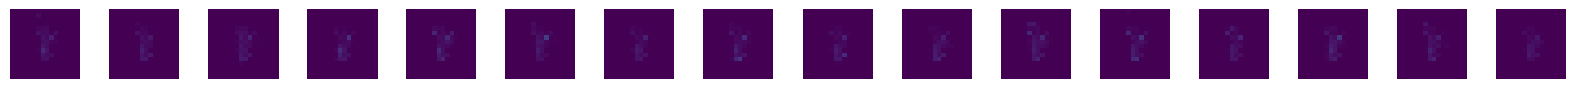

[Epoch 73/300] [D loss: 0.4737] [G loss: 0.6417] [Validity_loss: 0.5017] 
 [Stat_loss: 0.1377] [NNZ_loss: 0.0023]
Sample feature coding: [ 1.         -1.7287455   0.6252861   0.10198864  0.62623096  0.00658362
  0.07905975  0.00391824  0.0303489 ]


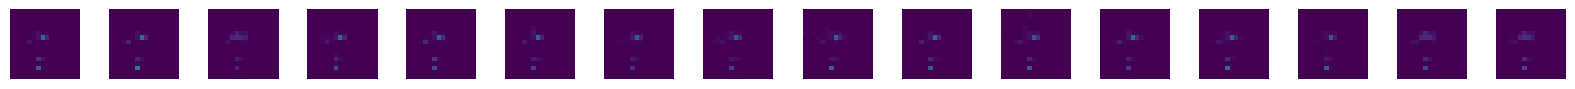

KeyboardInterrupt: 

In [8]:
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.to(device)
            real_flipped_feat = flipped_features.to(device)
            real_img = real_image.unsqueeze(1).to(device)
            real_flipped_img = flipped_image.unsqueeze(1).to(device)
    
            # print(f"Real: {real_img.shape}")
    
            # Codings should be label, eta, pT, mass that get passed directly to the discriminator
            # Other values get passed to the generator, then the output image passed to the discriminator
            
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
                
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
    
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)
    
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).to(device)
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)
    
                d_loss.backward()
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                # generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
    
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
    
                # Fooled discriminator loss
                d_out = discriminator(fake_img, fake_disc_codings)
                d_out_flip = discriminator(fake_flipped_img, fake_flipped_disc_codings)
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
    
                target = torch.ones_like(d_out)
                bce = nn.BCELoss()
                validity_loss = bce(d_out, target) + bce(d_out_flip, target)
    
                ## Stat loss
                # Compute fake statistics
                fake_stats = compute_fake_statistics(fake_img, dists)
    
                fake_dR_mean = fake_stats['fake_dR_mean']
                fake_dR_std = fake_stats['fake_dR_std']
                fake_pixel_mean = fake_stats['fake_pixel_mean']
                fake_pixel_std = fake_stats['fake_pixel_std']
    
                # Get real stats from z_codings (features 5–8)
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
    
                real_stats = {
                    'real_dR_mean': real_dR_mean,
                    'real_dR_std': real_dR_std,
                    'real_pixel_mean': real_pixel_mean,
                    'real_pixel_std': real_pixel_std
                }
    
                if n_epochs - epoch <= 10:
                    # Track the last statistics
                    track_statistics(stats_dict, fake_stats, real_stats)
    
                # Statistical MSE loss
                # dR_mean_loss = (torch.nn.MSELoss()(fake_dR_mean, real_dR_mean) + torch.nn.MSELoss()(flipped_dR_mean, real_dR_mean))
                # dR_std_loss = (torch.nn.MSELoss()(fake_dR_std, real_dR_std) + torch.nn.MSELoss()(flipped_dR_std, real_dR_std))
                # pixel_mean_loss = (torch.nn.MSELoss()(fake_pixel_mean, real_pixel_mean) + torch.nn.MSELoss()(flipped_pixel_mean, real_pixel_mean))
                # pixel_std_loss = (torch.nn.MSELoss()(fake_pixel_std, real_pixel_std) + torch.nn.MSELoss()(flipped_pixel_std, real_pixel_std))
                
                # stat_loss = dR_mean_loss + dR_std_loss + 3*pixel_mean_loss + 2*pixel_std_loss
    
                # print(dR_mean_loss)
                # print(dR_std_loss)
                # print(3*pixel_mean_loss)
                # print(2*pixel_std_loss)
    
                # Statistical KL Divergence loss
                kl_total = 0
                kl1 = kde_kl_divergence_torch(real_dR_mean, fake_dR_mean) / 0.03
                # print(f"KL(real_dR_mean, fake_dR_mean) = {kl1.item()}")
                
                kl2 = kde_kl_divergence_torch(real_dR_std, fake_dR_std) / 0.003
                # print(f"KL(real_dR_std, fake_dR_std) = {kl2.item()}")
                
                kl3 = kde_kl_divergence_torch(real_pixel_mean, fake_pixel_mean) / 0.0005  # Avoid division by zero
                # print(f"KL(real_pixel_mean, fake_pixel_mean) = {kl3.item()}")
                
                kl4 = kde_kl_divergence_torch(real_pixel_std, fake_pixel_std) / 0.0001
                # print(f"KL(real_pixel_std, fake_pixel_std) = {kl4.item()}")
                
                kl_total = kl1 + kl2 + kl3 + kl4
    
    
                stat_loss = kl_total
    
                # Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-5, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-5, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)
    
                
                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + the difference between input and output dR and pixel statistics
    
                alpha = .2
                beta = .00002
                chi = .03
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)
    
                g_loss.backward()
                optimizer_G.step()
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
    
        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[-1]:.4f}] [G loss: {g_losses[-1]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 
    
        plot_generated_samples(generator, dataset, kdes, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            # Save model states and tracked data in a single file
            save_path = f"models/1_layer_Fully_connected_QGAN_works_really_well_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "stats_dict": stats_dict
            }, save_path)
            
            print(f"Model and statistics saved to {save_path}")
    
    plot_metrics(g_losses, d_losses)
    
    plot_tracked_statistics(stats_dict)

In [9]:
## Save Model
# Create output directory if it doesn't exist
save = True

if save:
    os.makedirs("models", exist_ok=True)
    
    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/1_layer_Fully_connected_QGAN_works_really_well_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "stats_dict": stats_dict
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/1_layer_Fully_connected_QGAN_works_really_well_m21_1013.pt


![image.png](attachment:7aee3b98-579c-4bcb-9682-eb417b7e3a7a.png)

In [ ]:
plot_real_samples(dataset)

Sample feature coding: [ 1.         -0.8351473   0.95917827  0.928877    0.6909277   0.01184907
  0.08419275  0.00386818  0.0177446 ]


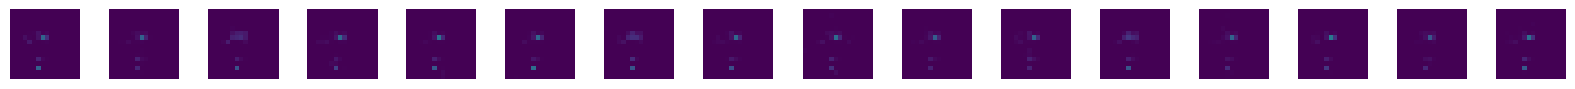

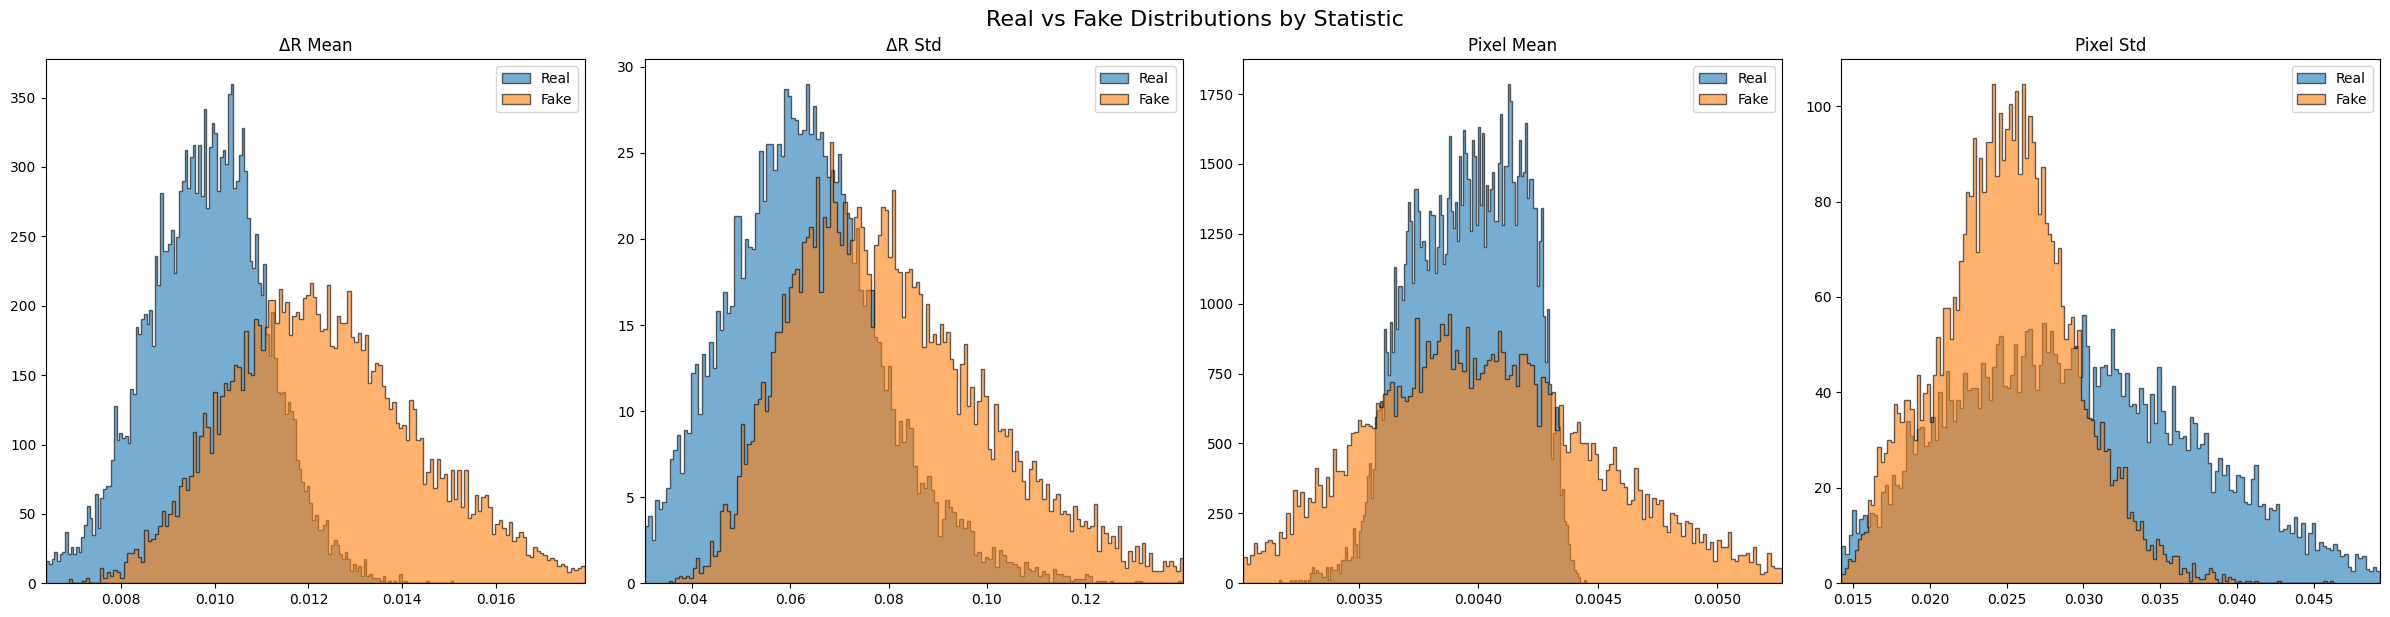

Discriminator output (wrong label): [0.30791953 0.19399975 0.2507343  ... 0.4714651  0.23355655 0.7620187 ]
Discriminator output (correct label): [0.40281314 0.6382642  0.7561133  ... 0.4003898  0.8068272  0.47520396]
Real labels: [1. 1. 1. ... 1. 1. 1.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [-23.557722 -69.6051   -66.83906  ...  17.751526 -71.05247   60.35613 ]


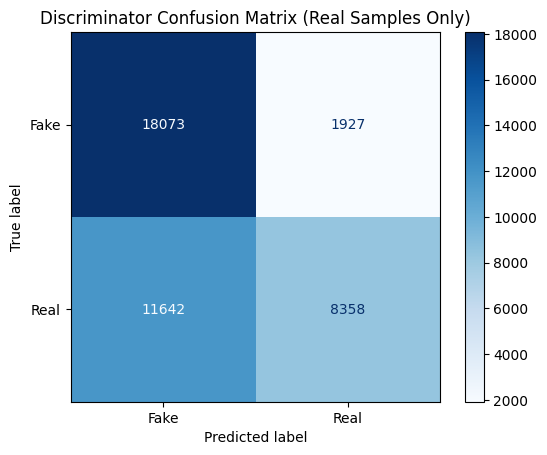

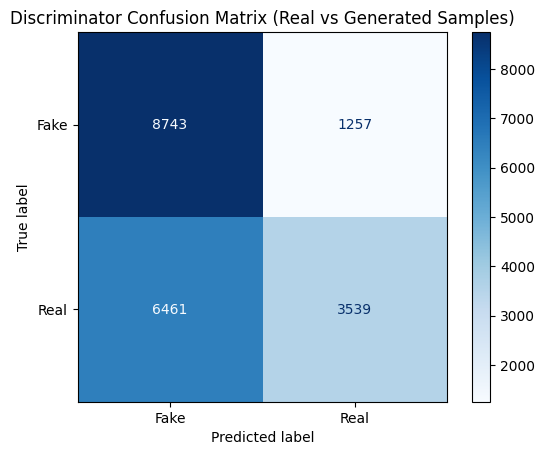

In [10]:
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=10000)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True